In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [18]:
df = pd.read_csv("Data/big_mart_sales.csv")

df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [19]:
df.shape

(8523, 12)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [11]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [23]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (8523, 12)

Columns:
Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

Missing values:
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


In [24]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (8523, 12)

Columns:
Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

Missing values:
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


In [26]:
sales_median = df["Item_Outlet_Sales"].median()

df["Sales_Class"] = (
    df["Item_Outlet_Sales"] >= sales_median
).astype(int)

print("Median Sales:", sales_median)

print(df["Sales_Class"].value_counts())

Median Sales: 1794.331
Sales_Class
1    4266
0    4257
Name: count, dtype: int64


In [27]:
X = df[
    [
        "Item_Weight",
        "Item_Visibility",
        "Item_MRP",
        "Outlet_Establishment_Year"
    ]
]

y = df["Sales_Class"]

In [28]:
X = X.fillna(X.median())

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6818, 4)
Testing data: (1705, 4)


In [30]:
dt_classifier = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [31]:
y_pred = dt_classifier.predict(X_test)

print(y_pred[:20])

[0 1 1 1 0 1 1 0 1 1 0 0 1 0 1 1 0 0 0 0]


In [32]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Decision Tree Classification Accuracy: {accuracy * 100:.2f}%")

Decision Tree Classification Accuracy: 77.18%


In [33]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Low Sales", "High Sales"]
))

              precision    recall  f1-score   support

   Low Sales       0.80      0.73      0.76       852
  High Sales       0.75      0.81      0.78       853

    accuracy                           0.77      1705
   macro avg       0.77      0.77      0.77      1705
weighted avg       0.77      0.77      0.77      1705



In [34]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[622 230]
 [159 694]]


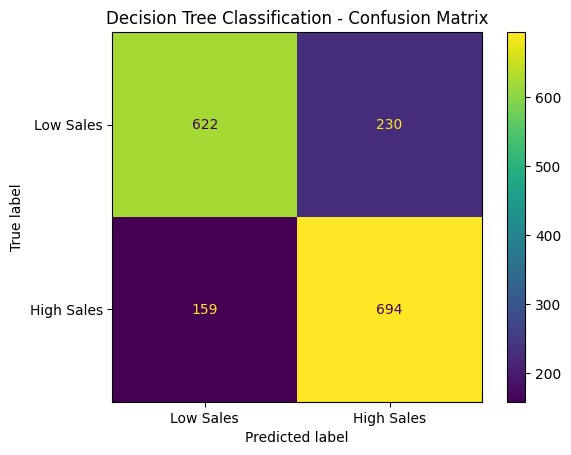

In [35]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low Sales", "High Sales"]
)

disp.plot()
plt.title("Decision Tree Classification - Confusion Matrix")
plt.show()

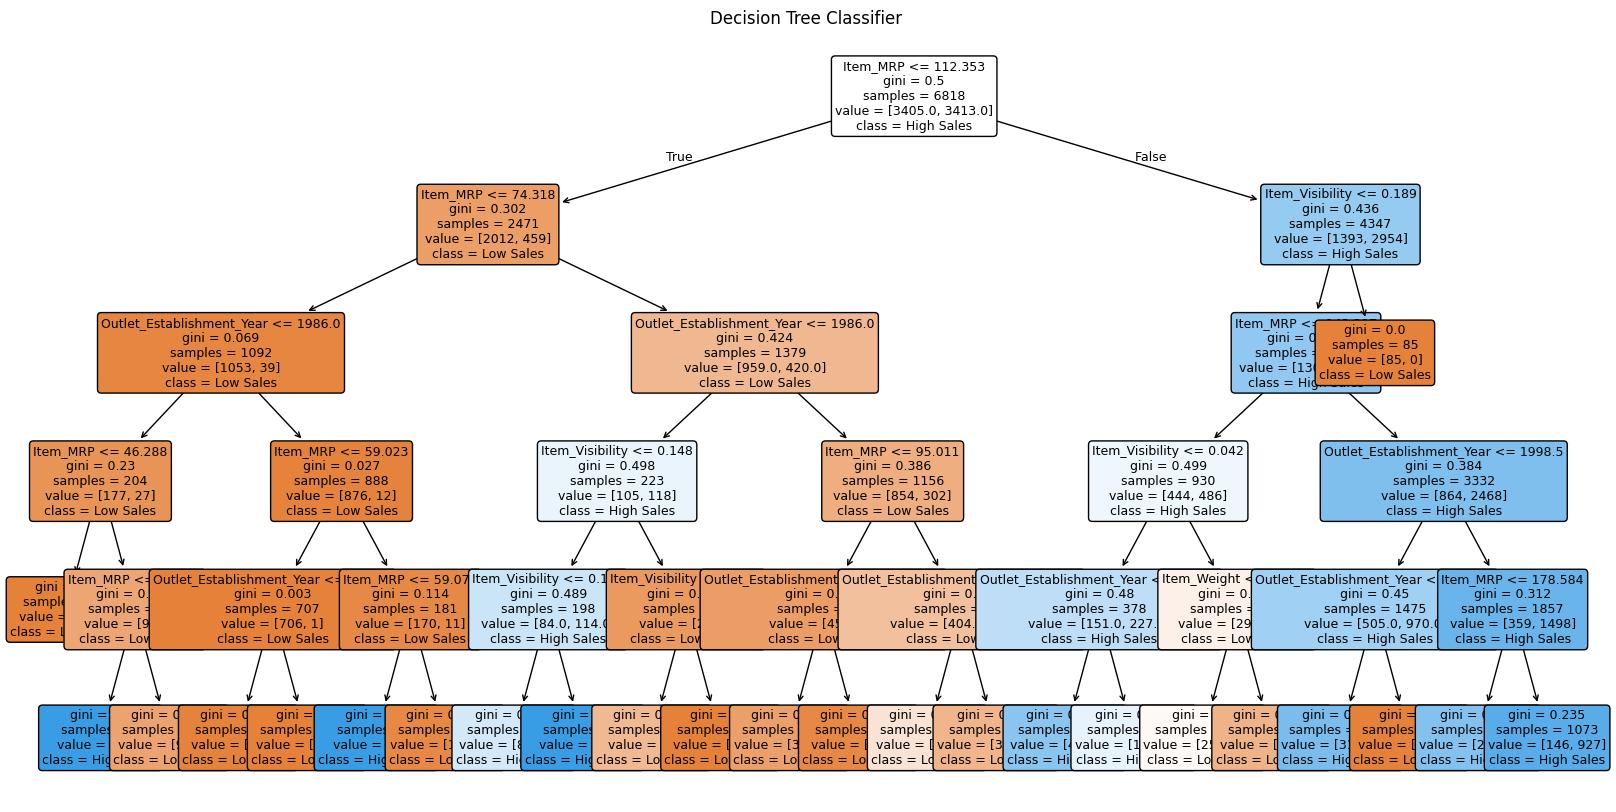

In [37]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_classifier,
    feature_names=X.columns,
    class_names=["Low Sales", "High Sales"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree Classifier")
plt.show()

In [38]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_classifier.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                     Feature  Importance
2                   Item_MRP    0.722952
3  Outlet_Establishment_Year    0.200349
1            Item_Visibility    0.073990
0                Item_Weight    0.002709


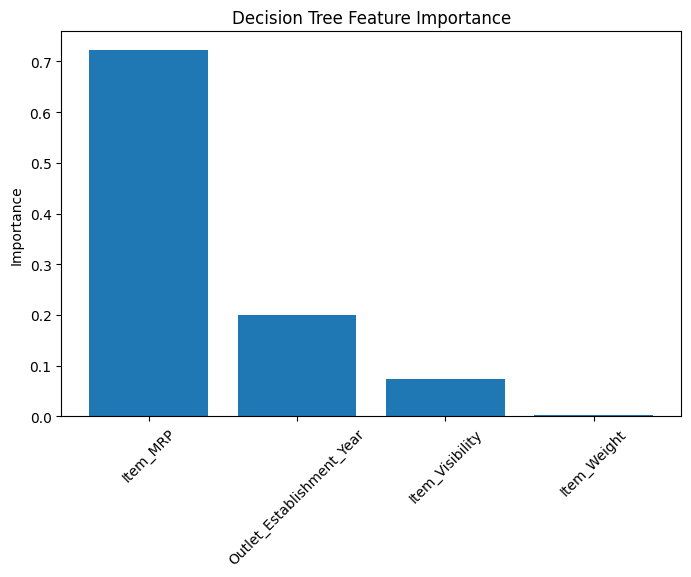

In [39]:
plt.figure(figsize=(8, 5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Decision Tree Feature Importance")
plt.show()

In [40]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [41]:
X = df[
    [
        "Item_Weight",
        "Item_Visibility",
        "Item_MRP",
        "Outlet_Establishment_Year"
    ]
]

y = df["Item_Outlet_Sales"]

In [42]:
X = X.fillna(X.median())

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (6818, 4)
X_test: (1705, 4)


In [44]:
dt_regressor = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=8,
    random_state=42
)

dt_regressor.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, random_state=42)

In [45]:
y_pred = dt_regressor.predict(X_test)

print(y_pred[:10])

[1386.27284751  777.04587312  744.33722449 3794.82598119 3086.40807866
  570.48816923 1931.72938537 1772.49976842 1579.0490839  3086.40807866]


In [46]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 909.5803582860908


In [48]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 1742299.6240242266


In [49]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 1319.9619782494594


In [50]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.35897026776567553


In [51]:
print("=" * 50)
print("DECISION TREE REGRESSION RESULTS")
print("=" * 50)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

DECISION TREE REGRESSION RESULTS
MAE  : 909.58
MSE  : 1742299.62
RMSE : 1319.96
R²   : 0.3590


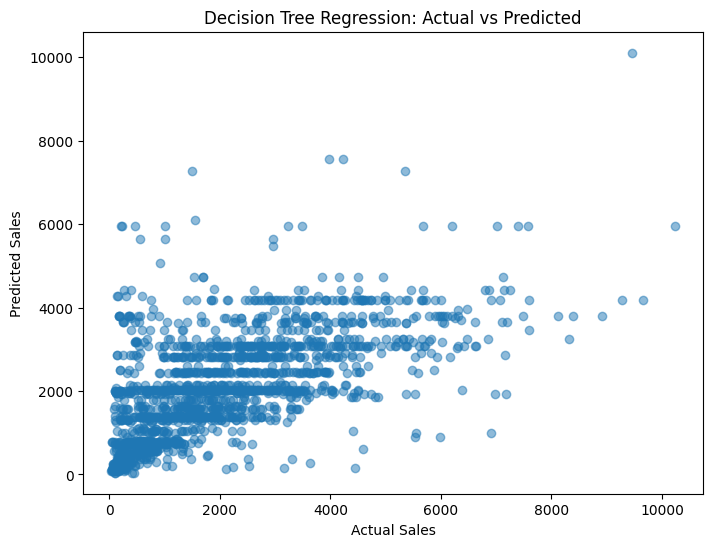

In [52]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Decision Tree Regression: Actual vs Predicted")

plt.show()

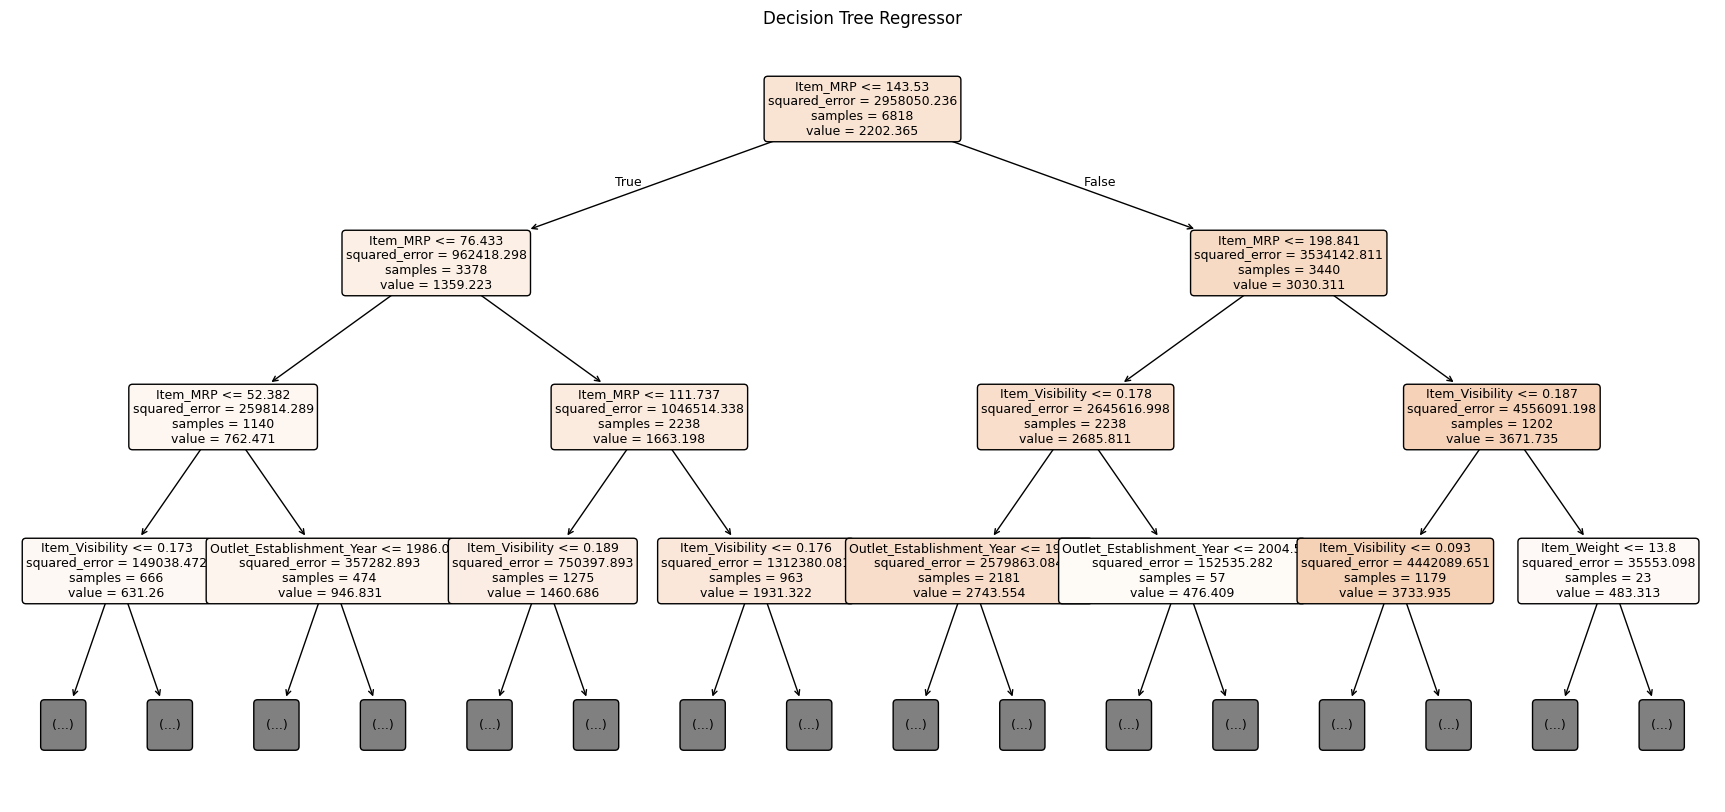

In [53]:
plt.figure(figsize=(22, 10))

plot_tree(
    dt_regressor,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree Regressor")
plt.show()

In [54]:
importance_reg = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_regressor.feature_importances_
})

importance_reg = importance_reg.sort_values(
    by="Importance",
    ascending=False
)

print(importance_reg)

                     Feature  Importance
2                   Item_MRP    0.684809
3  Outlet_Establishment_Year    0.176005
1            Item_Visibility    0.125904
0                Item_Weight    0.013282


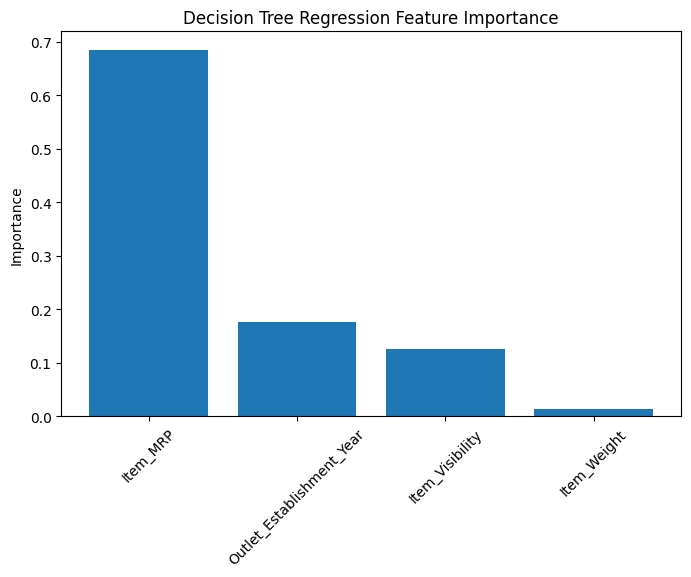

In [55]:
plt.figure(figsize=(8, 5))

plt.bar(
    importance_reg["Feature"],
    importance_reg["Importance"]
)

plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Decision Tree Regression Feature Importance")

plt.show()

In [56]:
print("\n" + "=" * 60)
print("DECISION TREE ALGORITHMS")
print("=" * 60)

print("\n1. CLASSIFICATION")
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\n2. REGRESSION")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")


DECISION TREE ALGORITHMS

1. CLASSIFICATION
Accuracy: 77.18%

2. REGRESSION
MAE : 909.58
RMSE: 1319.96
R²  : 0.3590
